In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')

# Load the detailed dataset (298 granular components)
df = pd.read_csv('cleaned_detailed_inflation.csv')

# Convert time column to datetime
df['time'] = pd.to_datetime(df['time'],dayfirst=True)

# Extract year and month for analysis
df['Year'] = df['time'].dt.year
df['Month'] = df['time'].dt.month

# Sort the dataframe by time
df = df.sort_values('time').reset_index(drop=True)

# Load weights
with open('detailed_weights.json', 'r') as f:
    weights = json.load(f)

In [2]:
# Exclude synthetic/calculated columns AND top-level aggregates
meta_cols = ['time', 'Year', 'Month', 'Month_Name']

# For detailed data, we keep all granular items
# Only exclude if there are any aggregate indices (usually none in detailed data)
EXCLUDE_EXACT = set()

EXCLUDE_KEYWORDS = [
    'Custom Index', 'Core Index', 'Core Bottom Up', 'Core Ex TnC',
    'Core Core Exc', 'Exclusion Index', 'RBI Core Index', 'Protein Index',
    '(ExVeggies)', 'exclude Food'
]

def is_excluded(colname: str) -> bool:
    """Check if column should be excluded"""
    if colname in EXCLUDE_EXACT:
        return True
    for kw in EXCLUDE_KEYWORDS:
        if kw.lower() in colname.lower():
            return True
    return False

# Get CPI component columns (all granular items)
candidates = [c for c in df.columns if c not in meta_cols]
cpi_cols = [c for c in candidates if not is_excluded(c) and not c.endswith('_YoY') and not c.endswith('_MoM')]

print(f"Total granular CPI components: {len(cpi_cols)}")

Total granular CPI components: 298


In [4]:
# Get latest and previous month indices
latest_idx = df.index[-1]
prev_idx = df.index[-2]

latest_date = df.loc[latest_idx, 'time'].strftime('%B %Y')
prev_date = df.loc[prev_idx, 'time'].strftime('%B %Y')

# Calculate month-on-month changes for all components
rows = []
for col in cpi_cols:
    prev_v = df.loc[prev_idx, col]
    cur_v = df.loc[latest_idx, col]
    weight = weights.get(col, 0.0)
    
    if pd.notna(prev_v) and pd.notna(cur_v) and prev_v != 0:
        change = ((cur_v - prev_v) / prev_v) * 100
        # Only include if there's actual change
        if abs(change) > 0.01:
            rows.append({
                'Category': col,
                'MoM Change (%)': change,
                'Weight': weight
            })

# Create dataframe and sort by change
changes_df = pd.DataFrame(rows).sort_values('MoM Change (%)', ascending=False)

# Get top 10 increases and decreases
top_10_increases = changes_df[changes_df['MoM Change (%)'] > 0].head(10).copy()
top_10_decreases = changes_df[changes_df['MoM Change (%)'] < 0].tail(10).copy()

# Shorten category names for display
def shorten_name(s, max_len=40):
    """Shorten category names for better display with word wrapping"""
    # Handle special case for overall CPI first
    if s == 'Consumer Price Index':
        return 'Overall CPI'
    
    # Remove nested prefixes iteratively
    prefixes_to_remove = [
        'Consumer Price Index: ',
        'Food and Beverages: ',
        'Miscellaneous: ',
        'Clothing and Footwear: ',
        'Pan, Tobacco and Intoxicants: ',
        'Fuel and Light: ',
        'Housing: '
    ]
    
    # Keep removing prefixes until none match
    changed = True
    while changed:
        changed = False
        for prefix in prefixes_to_remove:
            if s.startswith(prefix):
                s = s[len(prefix):]
                changed = True
                break
    
    # If still too long, truncate intelligently
    if len(s) > max_len:
        s = s[:max_len-3] + '...'
    return s

top_10_increases['Display_Name'] = top_10_increases['Category'].apply(shorten_name)
top_10_decreases['Display_Name'] = top_10_decreases['Category'].apply(shorten_name)

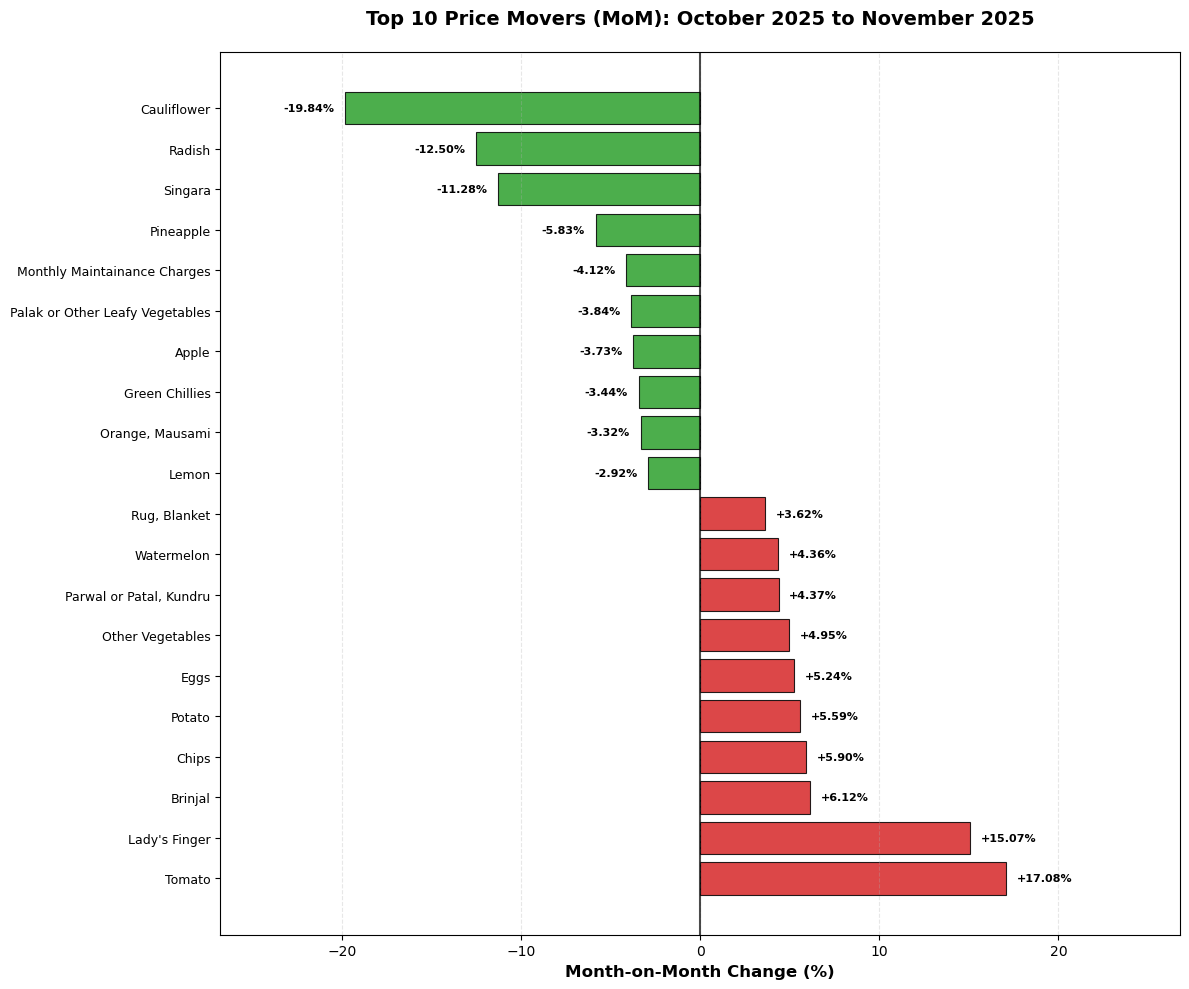

In [5]:
#| echo: false
#| warning: false
#| fig-width: 12
#| fig-height: 10
#| label: fig-top-changes-mom
#| fig-cap: "Top 10 Inflationary and Deflationary Items (Month-on-Month)"

# Create figure with proper spacing
fig, ax = plt.subplots(figsize=(12, 10))

# Prepare data
categories = list(top_10_increases['Display_Name']) + list(top_10_decreases['Display_Name'])
changes = list(top_10_increases['MoM Change (%)']) + list(top_10_decreases['MoM Change (%)'])

# Create positions for bars
y_positions = np.arange(len(categories))

# Color bars based on positive/negative
colors = ['#d62728' if x > 0 else '#2ca02c' for x in changes]

# Create horizontal bar chart
bars = ax.barh(y_positions, changes, color=colors, alpha=0.85, edgecolor='black', linewidth=0.8)

# Calculate x-axis range with padding for labels
max_val = max(abs(min(changes)), abs(max(changes)))
ax.set_xlim([-max_val * 1.35, max_val * 1.35])

# Add value labels at the end of bars without impact
for i, (pos, val) in enumerate(zip(y_positions, changes)):
    if val > 0:
        ax.text(val + max_val * 0.03, pos, f'{val:+.2f}%', 
               va='center', ha='left', fontsize=8, fontweight='bold', color='black')
    else:
        ax.text(val - max_val * 0.03, pos, f'{val:+.2f}%', 
               va='center', ha='right', fontsize=8, fontweight='bold', color='black')

# Customize plot
ax.set_yticks(y_positions)
ax.set_yticklabels(categories, fontsize=9)
ax.set_xlabel('Month-on-Month Change (%)', fontweight='bold', fontsize=12)
ax.set_title(f'Top 10 Price Movers (MoM): {prev_date} to {latest_date}', 
             fontweight='bold', fontsize=14, pad=20)
ax.axvline(x=0, color='black', linewidth=1.5, linestyle='-', alpha=0.7)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Remove legend
plt.tight_layout()
plt.show()

In [6]:
latest_idx_yoy = df.index[-1]
year_ago_idx = df.index[-13] if len(df) >= 13 else df.index[0]

latest_date_yoy = df.loc[latest_idx_yoy, 'time'].strftime('%B %Y')
year_ago_date_yoy = df.loc[year_ago_idx, 'time'].strftime('%B %Y')

# Calculate year-on-year changes for all components
rows_yoy = []
for col in cpi_cols:
    year_ago_v = df.loc[year_ago_idx, col]
    cur_v = df.loc[latest_idx_yoy, col]
    weight = weights.get(col, 0.0)
    
    if pd.notna(year_ago_v) and pd.notna(cur_v) and year_ago_v != 0:
        change = ((cur_v - year_ago_v) / year_ago_v) * 100
        if abs(change) > 0.01:
            rows_yoy.append({
                'Category': col,
                'YoY Change (%)': change,
                'Weight': weight
            })

# Create dataframe and sort by change
changes_yoy_df = pd.DataFrame(rows_yoy).sort_values('YoY Change (%)', ascending=False)

# Get top 10 increases and decreases
top_10_increases_yoy = changes_yoy_df[changes_yoy_df['YoY Change (%)'] > 0].head(10).copy()
top_10_decreases_yoy = changes_yoy_df[changes_yoy_df['YoY Change (%)'] < 0].tail(10).copy()

# Shorten category names
top_10_increases_yoy['Display_Name'] = top_10_increases_yoy['Category'].apply(shorten_name)
top_10_decreases_yoy['Display_Name'] = top_10_decreases_yoy['Category'].apply(shorten_name)

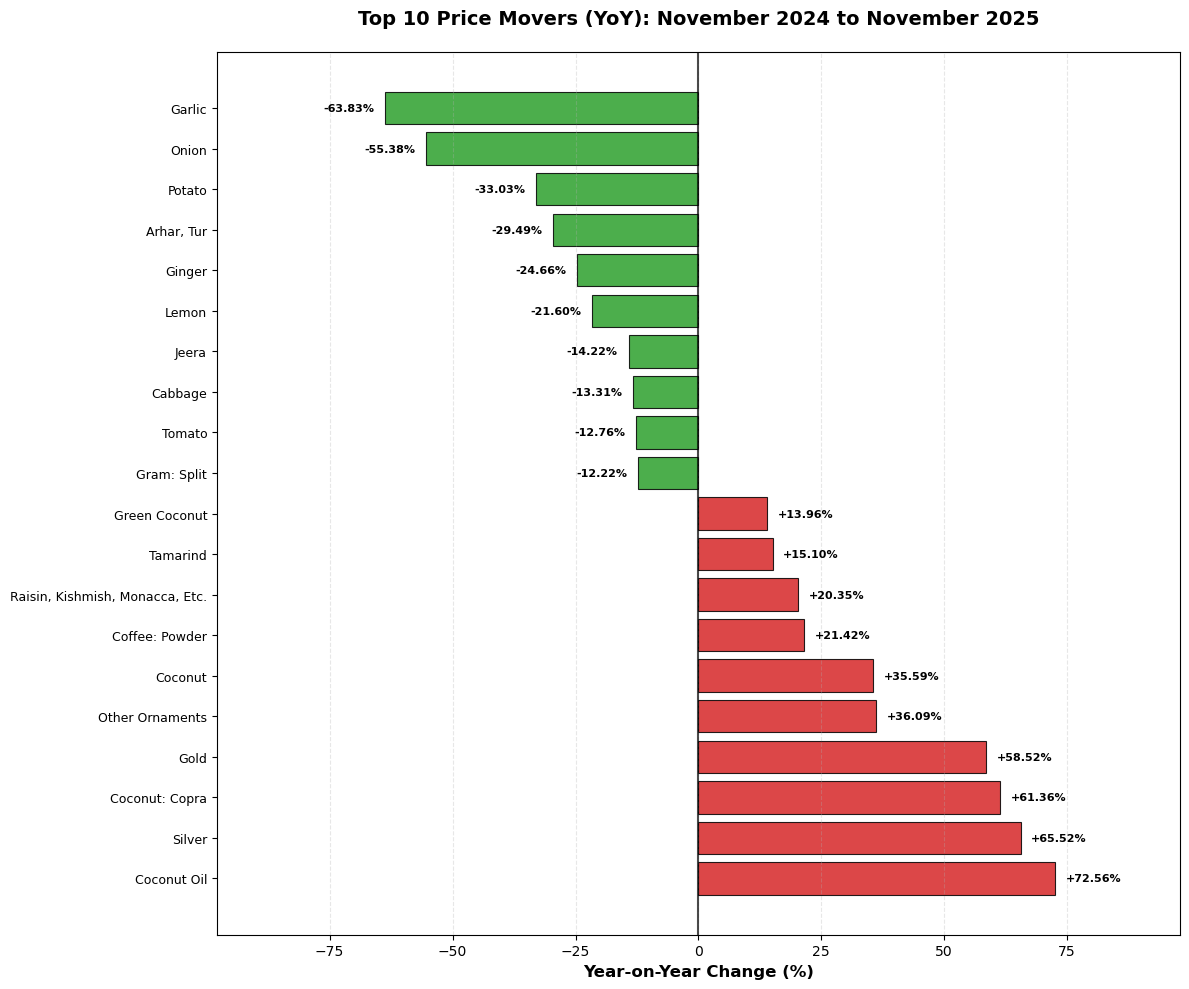

In [7]:
#| echo: false
#| warning: false
#| fig-width: 12
#| fig-height: 10
#| label: fig-top-changes-yoy
#| fig-cap: "Top 10 Inflationary and Deflationary Items (Year-on-Year)"

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Prepare data
categories_yoy = list(top_10_increases_yoy['Display_Name']) + list(top_10_decreases_yoy['Display_Name'])
changes_yoy = list(top_10_increases_yoy['YoY Change (%)']) + list(top_10_decreases_yoy['YoY Change (%)'])

# Create positions for bars
y_positions_yoy = np.arange(len(categories_yoy))

# Color bars based on positive/negative
colors_yoy = ['#d62728' if x > 0 else '#2ca02c' for x in changes_yoy]

# Create horizontal bar chart
bars = ax.barh(y_positions_yoy, changes_yoy, color=colors_yoy, alpha=0.85, edgecolor='black', linewidth=0.8)

# Calculate x-axis range with padding for labels
max_val_yoy = max(abs(min(changes_yoy)), abs(max(changes_yoy)))
ax.set_xlim([-max_val_yoy * 1.35, max_val_yoy * 1.35])

# Add value labels at the end of bars without impact
for i, (pos, val) in enumerate(zip(y_positions_yoy, changes_yoy)):
    if val > 0:
        ax.text(val + max_val_yoy * 0.03, pos, f'{val:+.2f}%', 
               va='center', ha='left', fontsize=8, fontweight='bold', color='black')
    else:
        ax.text(val - max_val_yoy * 0.03, pos, f'{val:+.2f}%', 
               va='center', ha='right', fontsize=8, fontweight='bold', color='black')

# Customize plot
ax.set_yticks(y_positions_yoy)
ax.set_yticklabels(categories_yoy, fontsize=9)
ax.set_xlabel('Year-on-Year Change (%)', fontweight='bold', fontsize=12)
ax.set_title(f'Top 10 Price Movers (YoY): {year_ago_date_yoy} to {latest_date_yoy}', 
             fontweight='bold', fontsize=14, pad=20)
ax.axvline(x=0, color='black', linewidth=1.5, linestyle='-', alpha=0.7)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Remove legend
plt.tight_layout()
plt.show()

In [8]:
#| echo: false
#| warning: false
# Filter data for the last 7 years
current_year = df['Year'].max()
df_last_7_years = df[df['Year'] >= current_year - 6].copy()

# Calculate YoY changes for dispersion analysis
yoy_cols = [f'{col}_YoY' for col in cpi_cols]

# Define inflation brackets
def classify_inflation(val):
    if pd.isna(val):
        return None
    elif val < 0:
        return 'Deflation (<0%)'
    elif val < 2:
        return 'Low (0-2%)'
    elif val < 4:
        return 'Moderate (2-4%)'
    elif val <= 6:
        return 'High (4-6%)'
    else:
        return 'Very High (>6%)'

# Create time series of dispersion
disp_df = []
for idx in df.index:
    row_data = {'time': df.loc[idx, 'time'], 'Year': df.loc[idx, 'Year'], 'Month': df.loc[idx, 'Month']}
    
    # Get YoY values for this month
    yoy_values = [df.loc[idx, col] for col in yoy_cols]
    yoy_values = [v for v in yoy_values if pd.notna(v)]
    
    if len(yoy_values) > 0:
        # Classify each component
        classifications = [classify_inflation(v) for v in yoy_values]
        
        # Count by bracket
        for bracket in ['Deflation (<0%)', 'Low (0-2%)', 'Moderate (2-4%)', 'High (4-6%)', 'Very High (>6%)']:
            count = classifications.count(bracket)
            row_data[bracket] = count
            row_data[f'{bracket}_pct'] = (count / len(yoy_values)) * 100
        
        disp_df.append(row_data)

disp_df = pd.DataFrame(disp_df)

# Filter to last 7 years
disp_7y = disp_df[disp_df['Year'] >= current_year - 6].copy()

# Define categories for plotting
categories = ['Deflation (<0%)', 'Low (0-2%)', 'Moderate (2-4%)', 'High (4-6%)', 'Very High (>6%)']
colors = ['#3182bd', '#9ecae1', '#ffeda0', '#feb24c', '#f03b20']

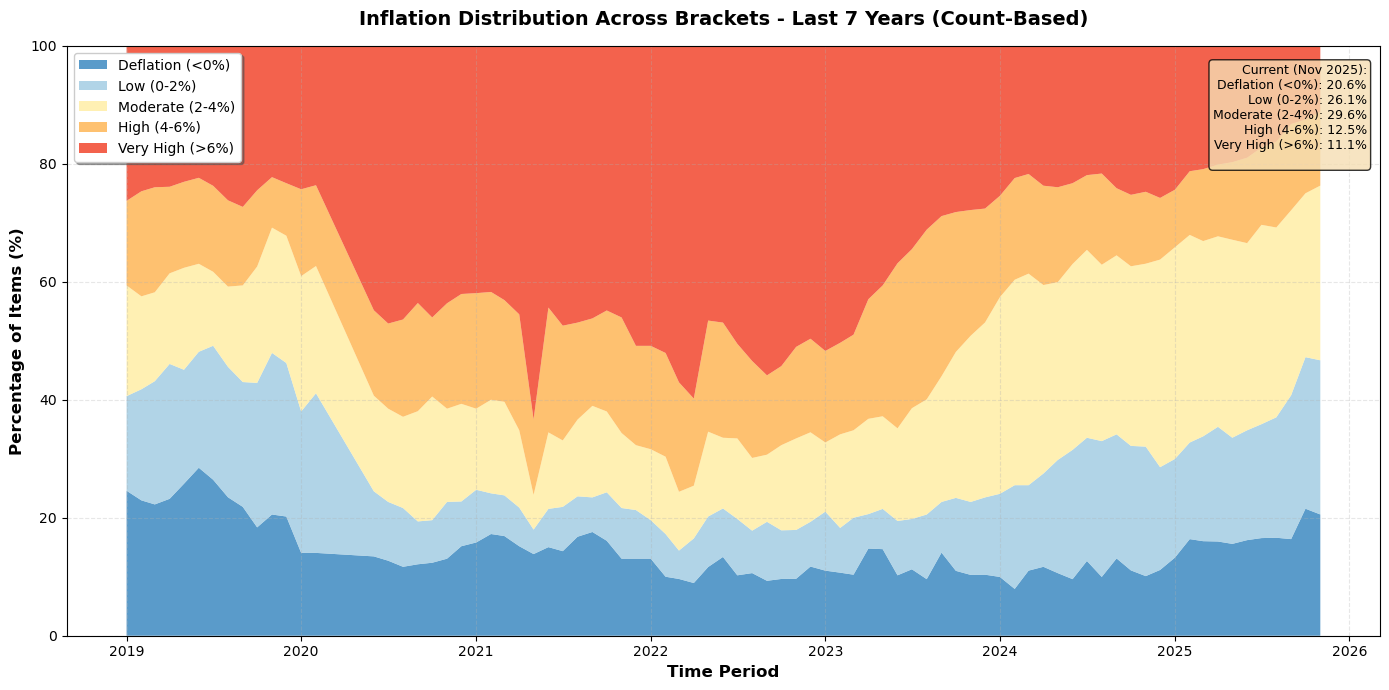

In [9]:
#| echo: false
#| warning: false
#| fig-width: 14
#| fig-height: 7
#| label: fig-dispersion-7y-norm-count
#| fig-cap: "Inflation Distribution by Bracket - Last 7 Years (Normalized, Count-Based)"

fig, ax = plt.subplots(figsize=(14, 7))

# Create stacked area for percentages
pct_cols = [f'{cat}_pct' for cat in categories]
ax.stackplot(disp_7y['time'], 
             *[disp_7y[col] for col in pct_cols],
             labels=categories,
             colors=colors,
             alpha=0.8)

ax.set_xlabel('Time Period', fontweight='bold', fontsize=12)
ax.set_ylabel('Percentage of Items (%)', fontweight='bold', fontsize=12)
ax.set_title('Inflation Distribution Across Brackets - Last 7 Years (Count-Based)', 
             fontweight='bold', fontsize=14, pad=15)
ax.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim([0, 100])

# Add current values annotation
if len(disp_7y) > 0:
    latest_disp = disp_7y.iloc[-1]
    latest_date = latest_disp['time'].strftime('%b %Y')
    annotation_text = f"Current ({latest_date}):\n"
    for cat in categories:
        pct = latest_disp[f'{cat}_pct']
        annotation_text += f"{cat}: {pct:.1f}%\n"
    
    ax.text(0.99, 0.97, annotation_text,
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()